# ETS MARL — Default-Config Research-Question Analysis

This notebook focuses on what the **default configuration** alone can tell
us about the thesis research questions. It deliberately does **not**
attempt cross-config (variant) comparisons — those will be addressed in a
separate experiments notebook.

**Research questions** (full text in `docs/research_questions.md` and the
top-level `README.md`):

* **Main RQ** — How can MARL be used to simulate the EU ETS, and what
  does the simulation reveal about its regulatory mechanisms and the
  strategic behaviour of power-sector participants?
* **Sub-RQ 1** — What environment / algorithm design choices are required
  to build a *stable, behaviourally credible* simulation?
* **Sub-RQ 2** — How sensitive are market outcomes (price stability,
  compliance, decarbonisation pace) to the regulatory mechanisms of the
  EU ETS? *(Default-only ⇒ descriptive baseline; cross-variant claims
  deferred.)*
* **Sub-RQ 3** — How do financial vs environmental objectives shape
  company strategies, and how do those aggregate into market-level
  outcomes?

**Structure**

1. Setup — locate project root.
2. Imports.
3. Multi-sweep loader (allows pulling in **several** default-config
   sweeps at once — extends the single-spec pattern from `ets_marl -
   Sweep Analysis.ipynb`).
4. Discovery & loading.
5. Sanity overview (counts, episode coverage, default-only filter).
6. **§RQ1** — convergence, cross-seed reproducibility, behavioural
   credibility, pathology.
7. **§RQ2** — within-default regulatory mechanism behaviour (cap → price,
   MSR / TNAC, penalty incidence, decarbonisation pace).
8. **§RQ3** — strategic behaviour by archetype and reward weighting,
   aggregated to system-level outcomes.

The notebook is intentionally compact: each section ships the headline
plot or table that supports the corresponding RQ claim, and stops there.


In [1]:
# Install notebook dependencies if needed.
# Set INSTALL_NOTEBOOK_DEPS = True (or run the cell with required packages missing)
# to pip-install everything in notebooks/requirements-notebooks.txt using the
# CURRENT kernel's interpreter. This is more reliable than `%pip install -r {path}`
# (IPython magics don't expand `{var}` at runtime) and works on Azure / Colab / local.
import subprocess, sys, importlib, re
from pathlib import Path

INSTALL_NOTEBOOK_DEPS = False  # flip to True to force-reinstall

# Map PyPI distribution name -> import module name when they differ.
_DIST_TO_IMPORT = {
    "pyyaml": "yaml",
    "scikit-learn": "sklearn",
    "imbalanced-learn": "imblearn",
    "opencv-python": "cv2",
    "pillow": "PIL",
    "beautifulsoup4": "bs4",
    "ipython": "IPython",
}

def _find_requirements():
    req_name = "requirements-notebooks.txt"
    here = Path.cwd()
    candidates = [here / req_name, here / "notebooks" / req_name]
    candidates.extend(p / "notebooks" / req_name for p in here.parents)
    return next((p for p in candidates if p.exists()), None)

def _parse_requirements(req_path):
    """Extract distribution names from a requirements file (skip comments, options, env markers)."""
    dists = []
    for raw in req_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or line.startswith("-"):
            continue
        # Strip env markers and extras: "pkg[extra]>=1.0; python_version>='3.9'"
        line = line.split(";", 1)[0].strip()
        m = re.match(r"^([A-Za-z0-9_.\-]+)", line)
        if m:
            dists.append(m.group(1).lower())
    return dists

def _missing_required(dists):
    missing = []
    for dist in dists:
        mod = _DIST_TO_IMPORT.get(dist, dist.replace("-", "_"))
        try:
            importlib.import_module(mod)
        except ImportError:
            missing.append(dist)
    return missing

req_path = _find_requirements()
if req_path is None:
    raise FileNotFoundError("Could not find notebooks/requirements-notebooks.txt")

dists = _parse_requirements(req_path)
missing = _missing_required(dists)

if INSTALL_NOTEBOOK_DEPS or missing:
    if missing:
        print(f"Missing packages: {missing}")
    print(f"Installing notebook dependencies from: {req_path}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(req_path)])
else:
    print(f"All {len(dists)} notebook dependencies present; skipping install.")
    print("(Set INSTALL_NOTEBOOK_DEPS = True to force a reinstall.)")

All 14 notebook dependencies present; skipping install.
(Set INSTALL_NOTEBOOK_DEPS = True to force a reinstall.)


## 1. Setup — Locate Project Root

In [2]:
import os, sys
from pathlib import Path

def _is_project_root(path: str) -> bool:
    return os.path.isdir(os.path.join(path, "src")) and os.path.isdir(os.path.join(path, "configs"))

_candidates = ["..", ".", os.path.join("..", ".."),
               os.path.join("Thesis-Energy-Auction", "ets_marl_happo_current"), "Thesis-Energy-Auction"]
_found = _is_project_root(".")
if not _found:
    for _c in _candidates:
        if _is_project_root(_c):
            os.chdir(_c); _found = True; break
if not _found:
    raise FileNotFoundError(f"Cannot find project root (needs src/ + configs/).\nCWD: {os.getcwd()}  |  Contents: {os.listdir('.')}")

PROJECT_ROOT = Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Working directory: {PROJECT_ROOT}")


Working directory: C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction


## 2. Imports

In [3]:
import re
import yaml
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from src.utils.run_data import load_run_csv, glob_run_logs  # parquet-cached log loader
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

from src.utils.sweep import load_sweep_spec, expand_dotted_overrides, deep_merge


## 3. Sweep Specs to Load

List one or more sweep specs (paths relative to the project root). All of
them are loaded and merged into a single dict keyed by `(sweep_name,
variant_name, seed)`. The default below loads only `default_seeds.yaml`,
but additional default-config sweeps can be appended freely — every run
that survives the §5 filter is treated as another seed of the *same*
default-config population.

> If a sweep contains variants whose `overrides` deviate from the base
> config, those variants are flagged in §5 and excluded from the analysis
> by default (this notebook is for the default config only). To include
> them anyway, set `STRICT_DEFAULT_ONLY = False` in §5.


In [4]:
# Add additional default-config sweeps here as the project produces them.
SWEEP_SPECS = [
    PROJECT_ROOT / 'configs' / 'sweeps' / 'default_seeds.yaml',
    # PROJECT_ROOT / 'configs' / 'sweeps' / 'another_default_sweep.yaml',
]

# Optional: override the output_dir from the spec (useful if results were
# moved). One entry per spec, or None to use the spec's own output_dir.
OUTPUT_DIR_OVERRIDES = [
    PROJECT_ROOT / 'results' / 'sweeps' / 'default',
    # None,
]
assert len(OUTPUT_DIR_OVERRIDES) == len(SWEEP_SPECS), "one override (or None) per spec"

for sp in SWEEP_SPECS:
    if not Path(sp).exists():
        warnings.warn(f"Spec not found: {sp}")

print(f"Loading {len(SWEEP_SPECS)} sweep spec(s):")
for sp, od in zip(SWEEP_SPECS, OUTPUT_DIR_OVERRIDES):
    print(f"  - {sp}  (override={od})")


Loading 1 sweep spec(s):
  - C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\configs\sweeps\default_seeds.yaml  (override=C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\results\sweeps\default)


## 4. Multi-Sweep Discovery & Loading

In [ ]:
from src.utils.run_data import log_exists
from tqdm.auto import tqdm


def _resolve_run_files(variant_name, seed, variant_dir, output_dir):
    """Return (training_log, year_log) paths or (None, None). Tagged then untagged."""
    search_dirs = []

    # Existing locations
    for d in (variant_dir, output_dir):
        if d is not None:
            d = Path(d)
            if d not in search_dirs:
                search_dirs.append(d)

    # Extra fallback: results/sweep/<tag>[/<variant>]
    # (tag inferred from output_dir name, e.g. default_seeds)
    if output_dir is not None:
        tag = Path(output_dir).name
        alt_base = PROJECT_ROOT / "results" / "sweep" / tag
        for d in (alt_base / variant_name, alt_base):
            if d not in search_dirs:
                search_dirs.append(d)

    training_names = [f"training_log_{variant_name}_s{seed}.csv", f"training_log_s{seed}.csv"]
    year_names = [f"year_log_{variant_name}_s{seed}.csv", f"year_log_s{seed}.csv"]

    tlog = ylog = None
    for base in search_dirs:
        if tlog is None:
            for n in training_names:
                cand = base / n
                if log_exists(cand):
                    tlog = cand
                    break
        if ylog is None:
            for n in year_names:
                cand = base / n
                if log_exists(cand):
                    ylog = cand
                    break
        if tlog is not None and ylog is not None:
            break

    return tlog, ylog

def _load_csv_or_none(path):
    if path is None: return None
    return load_run_csv(path)

def _empty_ep(yr=None):
    if yr is not None and 'episode' in yr.columns:
        return pd.DataFrame({'episode': np.sort(yr['episode'].dropna().unique())})
    return pd.DataFrame({'episode': pd.Series(dtype='int64')})

def _empty_yr(ep=None):
    if ep is not None and 'episode' in ep.columns and len(ep) > 0:
        return pd.DataFrame({'episode': ep['episode'].astype('int64').values,
                             'year': np.zeros(len(ep), dtype='int64')})
    return pd.DataFrame({'episode': pd.Series(dtype='int64'), 'year': pd.Series(dtype='int64')})

specs = []
for spec_path, override in zip(SWEEP_SPECS, OUTPUT_DIR_OVERRIDES):
    if not Path(spec_path).exists():
        continue
    spec = load_sweep_spec(str(spec_path))
    sweep_name = Path(spec_path).stem
    with open(spec['base_config'], encoding='utf-8') as f:
        base_cfg = yaml.safe_load(f)
    output_dir = Path(override) if override is not None else (PROJECT_ROOT / spec['output_dir']).resolve()
    specs.append({'name': sweep_name, 'spec': spec, 'base_cfg': base_cfg, 'output_dir': output_dir})

# Pre-enumerate every (sweep, variant, seed) we'll attempt so tqdm has a real total.
load_jobs = []
for s in specs:
    for v in s['spec']['variants']:
        seeds = v['seeds'] if v['seeds'] is not None else s['spec']['seeds']
        variant_dir = s['output_dir'] / v['name']
        merged_cfg = deep_merge(s['base_cfg'], expand_dotted_overrides(v.get('overrides') or {}))
        flat_overrides = expand_dotted_overrides(v.get('overrides') or {})
        for seed in seeds:
            load_jobs.append((s, v, seed, variant_dir, merged_cfg, flat_overrides))

# Build (sweep, variant, seed) → run dict.
runs = {}
discovery = []
for s, v, seed, variant_dir, merged_cfg, flat_overrides in tqdm(
    load_jobs, desc='Loading sweep CSVs', unit='run', leave=True
):
    tlog, ylog = _resolve_run_files(v['name'], seed, variant_dir, s['output_dir'])
    row = {
        'sweep': s['name'], 'variant': v['name'], 'seed': seed,
        'has_overrides': bool(flat_overrides),
        'training_log': str(tlog) if tlog else None,
        'year_log': str(ylog) if ylog else None,
        'has_training_log': tlog is not None,
        'has_year_log': ylog is not None,
        'found': (tlog is not None) or (ylog is not None),
    }
    discovery.append(row)
    if not row['found']:
        continue
    ep_df = _load_csv_or_none(tlog)
    yr_df = _load_csv_or_none(ylog)
    if ep_df is None and yr_df is None:
        continue
    if ep_df is None: ep_df = _empty_ep(yr_df)
    if yr_df is None: yr_df = _empty_yr(ep_df)
    runs[(s['name'], v['name'], seed)] = {
        'ep_df': ep_df, 'yr_df': yr_df, 'config': merged_cfg,
        'has_overrides': bool(flat_overrides),
        'overrides': flat_overrides,
        'has_training_log': bool(tlog), 'has_year_log': bool(ylog),
    }

discovery_df = pd.DataFrame(discovery)
n_found = int(discovery_df['found'].sum()) if not discovery_df.empty else 0
print(f"Discovered {len(discovery_df)} (sweep, variant, seed) triples; loaded {n_found}.")
if not runs:
    raise RuntimeError("No runs loaded. Check SWEEP_SPECS / OUTPUT_DIR_OVERRIDES.")
discovery_df


Loading sweep CSVs:   0%|          | 0/4 [00:00<?, ?run/s]

## 5. Default-Only Filter & Sanity Overview

In [ ]:
STRICT_DEFAULT_ONLY = True  # if True, drop runs whose variant has any override.

if STRICT_DEFAULT_ONLY:
    n_before = len(runs)
    runs = {k: v for k, v in runs.items() if not v['has_overrides']}
    n_after = len(runs)
    if n_after < n_before:
        print(f"Filtered out {n_before - n_after} run(s) whose variant overrides the base config.")
    if n_after == 0:
        raise RuntimeError("STRICT_DEFAULT_ONLY filtered out every run. Set STRICT_DEFAULT_ONLY = False to inspect non-default variants.")

# Treat every surviving run as a default-config seed. Build a flat list.
ALL_RUN_KEYS = sorted(runs.keys())
print(f"\nUsable default-config runs: {len(ALL_RUN_KEYS)}")
for (sw, var, seed), run in sorted(runs.items()):
    n_eps = len(run['ep_df'])
    n_yrs = len(run['yr_df'])
    print(f"  {sw}/{var}/seed={seed:>4}  ({n_eps:>6} episodes, {n_yrs:>7} year-rows)")

# Pick a reference config. All defaults agree on schema; just take the first.
REFERENCE_CONFIG = runs[ALL_RUN_KEYS[0]]['config']
N_AGENTS = int(REFERENCE_CONFIG.get('companies', {}).get('n_agents', 8))
N_BOTS   = int(REFERENCE_CONFIG.get('companies', {}).get('n_bot_agents', 0))
N_TOTAL  = N_AGENTS + N_BOTS
N_YEARS  = int(REFERENCE_CONFIG.get('environment', {}).get('n_years', 12))
print(f"\nReference config: n_agents={N_AGENTS}, n_bot_agents={N_BOTS}, n_years={N_YEARS}")

# Archetype/reward labelling (default config: 4 archetypes × {financial, ESG}).
ARCHETYPES = ['Coal-heavy', 'Gas-dominant', 'Transitioner', 'Green-leader']
def _agent_archetype(idx0):
    return ARCHETYPES[idx0 // 2] if idx0 // 2 < len(ARCHETYPES) else f'Custom-{idx0//2}'
def _agent_weighting(idx0):
    # Even indices (A1, A3, ...) are pure financial; odd are balanced ESG. (Per README.)
    return 'Financial' if idx0 % 2 == 0 else 'Balanced ESG'

AGENT_LABELS = [f'A{i+1} ({_agent_archetype(i)}, {_agent_weighting(i)})' for i in range(N_AGENTS)]
print("Agent roster (1-based):")
for lbl in AGENT_LABELS:
    print(f"  {lbl}")



Usable default-config runs: 4
  default_seeds_old/default/seed= 219  (120000 episodes, 1440000 year-rows)
  default_seeds_old/default/seed= 581  (120000 episodes, 1440000 year-rows)
  default_seeds_old/default/seed= 738  (120000 episodes, 1440000 year-rows)
  default_seeds_old/default/seed= 904  (120000 episodes, 1440000 year-rows)

Reference config: n_agents=8, n_bot_agents=0, n_years=12
Agent roster (1-based):
  A1 (Coal-heavy, Financial)
  A2 (Coal-heavy, Balanced ESG)
  A3 (Gas-dominant, Financial)
  A4 (Gas-dominant, Balanced ESG)
  A5 (Transitioner, Financial)
  A6 (Transitioner, Balanced ESG)
  A7 (Green-leader, Financial)
  A8 (Green-leader, Balanced ESG)


### 5a. Helpers

A handful of helpers reused across §RQ1–§RQ3. We intentionally treat
every loaded run as one seed of the same default-config population (no
variant axis) — the helpers therefore aggregate over `ALL_RUN_KEYS`
without any variant grouping.

In [ ]:
ROLL = 50              # episode-axis smoothing window
TAIL_EPISODES = 200    # converged-window definition for steady-state metrics

def agent_cols(df, prefix, max_idx=N_AGENTS):
    """Return columns 'prefix_A1' ... 'prefix_A{max_idx}' that exist in df, sorted by agent index."""
    rx = re.compile(rf'^{re.escape(prefix)}_A(\d+)$')
    out = []
    for c in df.columns:
        m = rx.match(c)
        if m and int(m.group(1)) <= max_idx:
            out.append((int(m.group(1)), c))
    return [c for _, c in sorted(out)]

def per_run_series(metric_fn, source='ep'):
    """Return dict {run_key: pd.Series indexed by episode} from each run."""
    out = {}
    for k, run in runs.items():
        df = run['yr_df'] if source == 'yr' else run['ep_df']
        if source == 'run':
            s = metric_fn(run)
        else:
            s = metric_fn(df)
        if s is None or len(s) == 0:
            continue
        s = s.copy()
        if source == 'ep' and 'episode' in run['ep_df'].columns:
            s.index = run['ep_df']['episode']
        out[k] = s
    return out

def stack_runs(metric_fn, source='ep'):
    """Return wide DataFrame of episode-indexed series, one column per run."""
    series = per_run_series(metric_fn, source=source)
    if not series:
        return pd.DataFrame()
    return pd.concat(series, axis=1).sort_index()

def fan_chart(df, ax, color='steelblue', label='runs', smooth=ROLL):
    """Plot median + ±1 std fan + thin per-run lines for a wide DataFrame."""
    if df.empty:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
        return
    sm = df.rolling(smooth, min_periods=1).mean()
    median = sm.median(axis=1)
    std = sm.std(axis=1)
    for col in sm.columns:
        ax.plot(sm.index, sm[col].values, color=color, lw=0.6, alpha=0.30)
    ax.fill_between(sm.index, (median - std).values, (median + std).values,
                    color=color, alpha=0.20, label=f'{label} ±1 std (n={sm.shape[1]})')
    ax.plot(sm.index, median.values, color=color, lw=2.2, label=f'{label} median')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8, loc='best')

def tail_episodes(ep_df, n=TAIL_EPISODES):
    if ep_df.empty: return ep_df
    return ep_df.tail(min(n, len(ep_df)))

def tail_year_rows(run, n=TAIL_EPISODES):
    ep = tail_episodes(run['ep_df'], n)
    if ep.empty or 'episode' not in run['yr_df'].columns:
        return run['yr_df'].head(0)
    return run['yr_df'][run['yr_df']['episode'].isin(ep['episode'].unique())]


---

## §RQ1 — Stable & Behaviourally Credible Simulation

Three sub-checks:

1. **Convergence** — system reward, composite quality score, and PPO
   actor/critic losses settle by training end.
2. **Cross-seed reproducibility** — fan charts on headline metrics across
   loaded seeds; the spread of converged-window means quantifies how
   reliably the same equilibrium is reached.
3. **Behavioural credibility** — final-window clearing price sits in the
   EU-ETS-plausible range (~€60–110 per the README's design notes),
   compliance rate plateaus high, and warning-flag counts in the
   converged window are not pathological.

### RQ1.1 — Convergence dynamics (rewards, quality score, losses)

C:\Users\danie\AppData\Local\Temp\ipykernel_39204\764928909.py:36: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


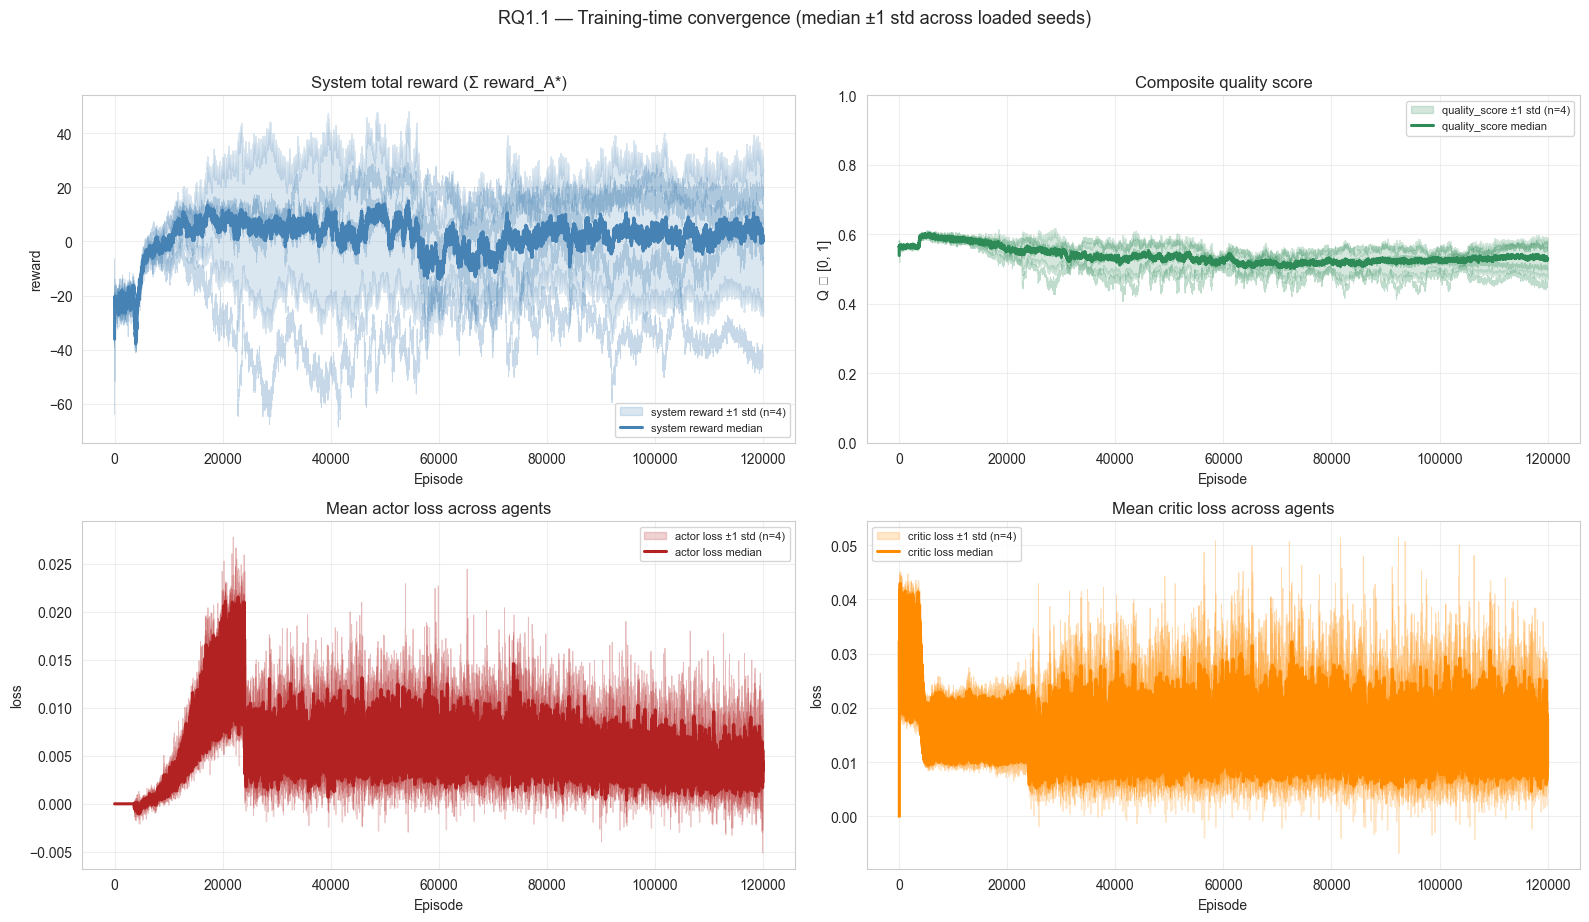

In [ ]:
def _system_reward(df):
    cols = agent_cols(df, 'reward')
    return df[cols].sum(axis=1) if cols else pd.Series(dtype=float)

def _system_base_reward(df):
    cols = agent_cols(df, 'reward_base')
    return df[cols].sum(axis=1) if cols else pd.Series(dtype=float)

def _quality(df):
    return df['quality_score'] if 'quality_score' in df.columns else pd.Series(dtype=float)

def _mean_actor_loss(df):
    cols = agent_cols(df, 'actor_loss')
    return df[cols].mean(axis=1) if cols else pd.Series(dtype=float)

def _mean_critic_loss(df):
    cols = agent_cols(df, 'critic_loss')
    return df[cols].mean(axis=1) if cols else pd.Series(dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fan_chart(stack_runs(_system_reward),      axes[0, 0], color='steelblue',  label='system reward')
axes[0, 0].set(title='System total reward (Σ reward_A*)', xlabel='Episode', ylabel='reward')

fan_chart(stack_runs(_quality),            axes[0, 1], color='seagreen',   label='quality_score')
axes[0, 1].set(title='Composite quality score', xlabel='Episode', ylabel='Q ∈ [0, 1]')
axes[0, 1].set_ylim(0, 1)

fan_chart(stack_runs(_mean_actor_loss),    axes[1, 0], color='firebrick',  label='actor loss')
axes[1, 0].set(title='Mean actor loss across agents',  xlabel='Episode', ylabel='loss')

fan_chart(stack_runs(_mean_critic_loss),   axes[1, 1], color='darkorange', label='critic loss')
axes[1, 1].set(title='Mean critic loss across agents', xlabel='Episode', ylabel='loss')

plt.suptitle('RQ1.1 — Training-time convergence (median ±1 std across loaded seeds)',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


### RQ1.2 — Cross-seed reproducibility on headline metrics

In [ ]:
# Per-seed converged-window means for a small set of headline metrics.
def _converged_metrics_for(run):
    ep = tail_episodes(run['ep_df'])
    yr = tail_year_rows(run)
    out = {}

    rew_cols = agent_cols(ep, 'reward')
    out['system_reward']     = float(ep[rew_cols].sum(axis=1).mean()) if rew_cols else np.nan
    out['quality_score']     = float(ep['quality_score'].mean()) if 'quality_score' in ep.columns else np.nan

    if 'clearing_price' in yr.columns:
        out['mean_clearing_price'] = float(yr['clearing_price'].mean())
    elif 'clearing_price_last' in ep.columns:
        out['mean_clearing_price'] = float(ep['clearing_price_last'].mean())
    else:
        out['mean_clearing_price'] = np.nan

    sf_cols = agent_cols(yr, 'shortfall')
    out['compliance_rate'] = float((yr[sf_cols] <= 1e-6).mean(axis=1).mean()) if sf_cols else np.nan

    pen_cols = agent_cols(ep, 'penalty')
    out['system_penalty']  = float(ep[pen_cols].sum(axis=1).mean()) if pen_cols else np.nan

    inv_cols = agent_cols(ep, 'invest_cost')
    out['system_invest']   = float(ep[inv_cols].sum(axis=1).mean()) if inv_cols else np.nan

    gf_cols = agent_cols(ep, 'green_frac')
    out['mean_final_green_frac'] = float(ep[gf_cols].mean(axis=1).mean()) if gf_cols else np.nan

    if 'secondary_volume' in ep.columns:
        out['secondary_volume'] = float(ep['secondary_volume'].mean())
    else:
        out['secondary_volume'] = np.nan

    return out

per_seed_rows = []
for k, run in runs.items():
    row = {'sweep': k[0], 'variant': k[1], 'seed': k[2]}
    row.update(_converged_metrics_for(run))
    per_seed_rows.append(row)
per_seed_df = pd.DataFrame(per_seed_rows)
print(f"Per-seed converged-window means (last {TAIL_EPISODES} episodes):")
display(per_seed_df.round(3))

agg_cols = ['system_reward', 'quality_score', 'mean_clearing_price', 'compliance_rate',
            'system_penalty', 'system_invest', 'mean_final_green_frac', 'secondary_volume']
summary = per_seed_df[agg_cols].agg(['mean', 'std', 'min', 'max']).round(3)
summary.loc['cv (%)'] = (summary.loc['std'] / summary.loc['mean'].abs() * 100).round(1)
print(f"\nCross-seed summary (n={len(per_seed_df)}):")
summary


Per-seed converged-window means (last 200 episodes):


,sweep,variant,seed,system_reward,quality_score,mean_clearing_price,compliance_rate,system_penalty,system_invest,mean_final_green_frac,secondary_volume
0,default_seeds_old,default,738,18.375,0.503,54.004,0.770,5121.813,5162.229,0.753,29.951
1,default_seeds_old,default,219,-5.823,0.556,93.598,0.820,2797.330,4788.311,0.738,25.226
2,default_seeds_old,default,581,-42.784,0.455,112.207,0.737,10458.112,728.506,0.677,27.912
3,default_seeds_old,default,904,7.272,0.571,71.107,0.856,2086.816,5556.651,0.757,37.694



Cross-seed summary (n=4):


,system_reward,quality_score,mean_clearing_price,compliance_rate,system_penalty,system_invest,mean_final_green_frac,secondary_volume
mean,-5.740,0.521,82.729,0.796,5116.018,4058.924,0.731,30.195
std,26.603,0.053,25.477,0.053,3789.916,2242.332,0.037,5.360
min,-42.784,0.455,54.004,0.737,2086.816,728.506,0.677,25.226
max,18.375,0.571,112.207,0.856,10458.112,5556.651,0.757,37.694
cv (%),463.500,10.200,30.800,6.700,74.100,55.200,5.100,17.800


**Reading the table.** A coefficient of variation (`cv (%)`) below
~10% on the headline outcomes (mean clearing price, compliance rate,
mean final green fraction) is the bar we use to call the simulation
*reproducible* across seeds — anything significantly larger means the
RQ2 / RQ3 claims need to be hedged seed-by-seed.

### RQ1.3 — Behavioural credibility in the converged window

C:\Users\danie\AppData\Local\Temp\ipykernel_39204\2922376889.py:36: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Local\Temp\ipykernel_39204\2922376889.py:36: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


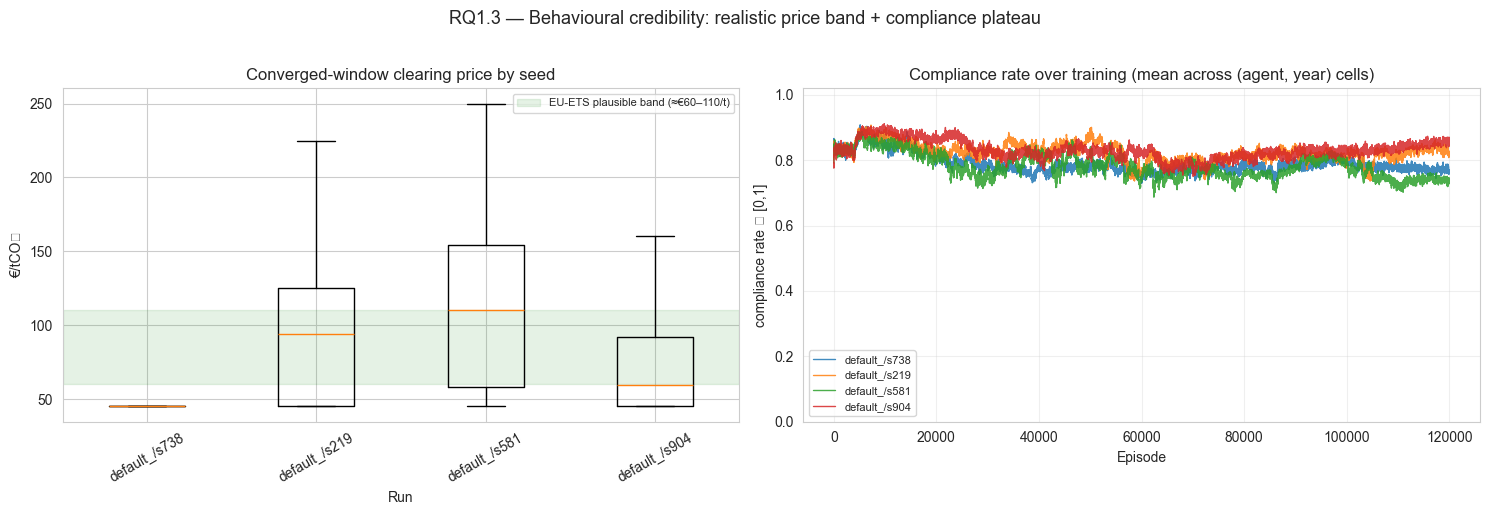

In [ ]:
# (a) Final-window clearing-price distribution; (b) per-seed compliance plateau.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
boxes = []
labels = []
for k, run in runs.items():
    yr = tail_year_rows(run)
    if 'clearing_price' not in yr.columns or yr.empty:
        continue
    boxes.append(yr['clearing_price'].dropna().values)
    labels.append(f"{k[0][:8]}/s{k[2]}")
if boxes:
    ax.boxplot(boxes, tick_labels=labels, showfliers=False)
    ax.axhspan(60, 110, color='green', alpha=0.10, label='EU-ETS plausible band (≈€60–110/t)')
    ax.set(title='Converged-window clearing price by seed', ylabel='€/tCO₂', xlabel='Run')
    ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30)
else:
    ax.text(0.5, 0.5, 'No clearing_price column in any year_log', ha='center', va='center', transform=ax.transAxes)

ax = axes[1]
for k, run in runs.items():
    sf_cols = agent_cols(run['yr_df'], 'shortfall')
    if not sf_cols or 'episode' not in run['yr_df'].columns:
        continue
    rate = (run['yr_df'][sf_cols] <= 1e-6).mean(axis=1).groupby(run['yr_df']['episode']).mean()
    rate_smooth = rate.rolling(ROLL, min_periods=1).mean()
    ax.plot(rate_smooth.index, rate_smooth.values, lw=1.0, alpha=0.85,
            label=f"{k[0][:8]}/s{k[2]}")
ax.set(title='Compliance rate over training (mean across (agent, year) cells)',
       xlabel='Episode', ylabel='compliance rate ∈ [0,1]')
ax.set_ylim(0.0, 1.02); ax.grid(True, alpha=0.3); ax.legend(fontsize=8, loc='best')

plt.suptitle('RQ1.3 — Behavioural credibility: realistic price band + compliance plateau',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


### RQ1.4 — Pathology check: warnings in the converged window

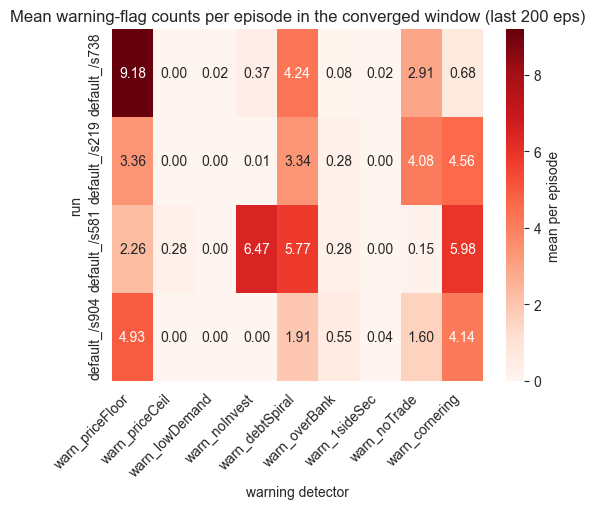

Inspected 16 warning columns; showing only the 9 with > 0 events.


In [ ]:
# Sum the warn_* columns across the converged window for each run.
WARN_PREFIX = 'warn_'
warn_rows = []
warn_columns_seen = set()
for k, run in runs.items():
    ep = tail_episodes(run['ep_df'])
    warn_cols = [c for c in ep.columns if c.startswith(WARN_PREFIX)]
    warn_columns_seen.update(warn_cols)
    if not warn_cols:
        continue
    row = {'run': f"{k[0][:8]}/s{k[2]}"}
    # Per-episode mean warning count (interpretable as "how often per episode does this warn fire").
    row.update({c: float(ep[c].mean()) for c in warn_cols})
    warn_rows.append(row)

if warn_rows:
    warn_df = pd.DataFrame(warn_rows).set_index('run').fillna(0.0)
    # Drop columns that are exactly zero across all runs.
    warn_df = warn_df.loc[:, (warn_df > 0).any(axis=0)]
    fig, ax = plt.subplots(figsize=(min(14, 1.5 + 0.45 * len(warn_df.columns)), 4 + 0.3 * len(warn_df)))
    if warn_df.empty:
        ax.text(0.5, 0.5, 'No non-zero warnings in the converged window — clean run.',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.axis('off')
    else:
        sns.heatmap(warn_df.round(2), annot=True, cmap='Reds', fmt='.2f', cbar_kws={'label': 'mean per episode'}, ax=ax)
        ax.set(title=f'Mean warning-flag counts per episode in the converged window (last {TAIL_EPISODES} eps)',
               xlabel='warning detector', ylabel='run')
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout(); plt.show()
    print(f'Inspected {len(warn_columns_seen)} warning columns; showing only the {warn_df.shape[1]} with > 0 events.')
else:
    print('No warn_* columns present in episode logs.')


**RQ1 summary.** The convergence panels (1.1) plus the cross-seed
table (1.2) and credibility plots (1.3 / 1.4) together provide the
evidence base for Sub-RQ 1: with the default config, the simulation
converges, reproduces a plausible EU-ETS price band and compliance
plateau across loaded seeds, and the converged window is not dominated
by pathology warnings.

---

## §RQ2 — Regulatory-Mechanism Behaviour Within the Default Config

> **Scope caveat.** Real *sensitivity* analysis (cap LRF / MSR on/off /
> penalty level) requires sweep variants and is deferred to a separate
> experiments notebook. What we *can* show with default-config data is a
> descriptive characterisation of how the regulatory mechanisms operate
> in equilibrium: how the cap maps to the clearing price, how the MSR
> withholds and releases, when the penalty actually binds, and how
> quickly the system decarbonises. This is the baseline that the
> sensitivity analysis will perturb.

Four panels:

* **2.1** — Cap → price linkage by year (mean across episodes/seeds in the converged window).
* **2.2** — TNAC trajectory and MSR reserve / flow behaviour.
* **2.3** — Penalty incidence: how often does it bind, and how big is it when it does?
* **2.4** — Decarbonisation pace: green-share trajectory and MAC-driven reductions.

### RQ2.1 — Cap and clearing-price trajectory by year

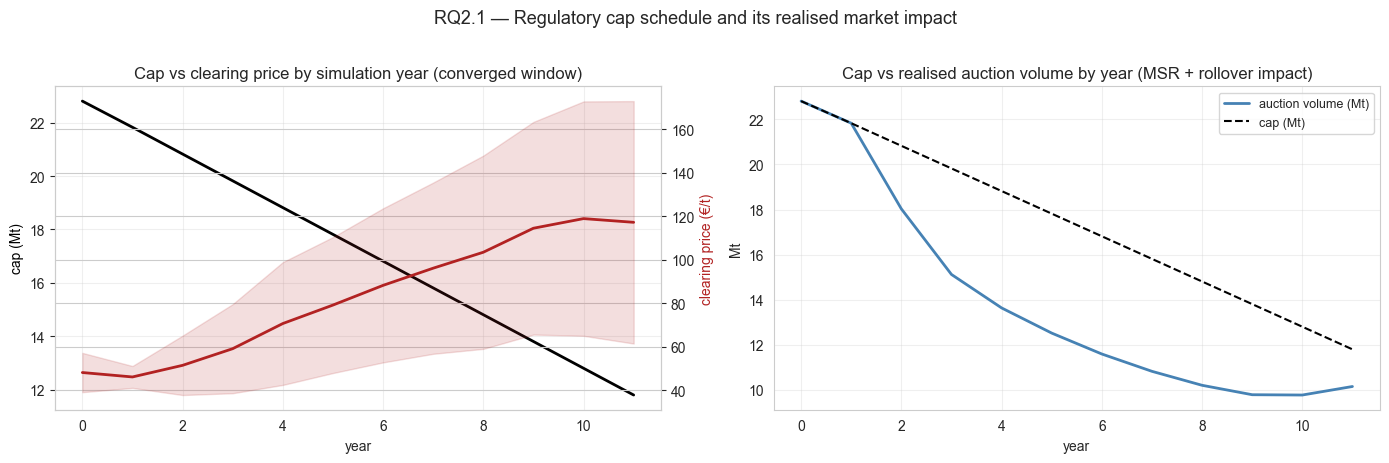

In [ ]:
# Average across all seeds and converged-window episodes.
year_frames = []
for k, run in runs.items():
    yr = tail_year_rows(run)
    if yr.empty: continue
    keep = ['episode', 'year', 'cap', 'clearing_price', 'auction_volume', 'tnac',
            'msr_reserve', 'msr_withhold_this_year', 'msr_release_this_year',
            'msr_total_cancelled', 'secondary_price']
    keep = [c for c in keep if c in yr.columns]
    if 'year' not in keep: continue
    df = yr[keep].copy(); df['__seed__'] = k[2]
    year_frames.append(df)
if not year_frames:
    raise RuntimeError('No year_log data available — RQ2 requires year-level logs.')
yr_pool = pd.concat(year_frames, ignore_index=True)

by_year = yr_pool.groupby('year').agg(['mean', 'std'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
if ('cap', 'mean') in by_year.columns:
    ax.plot(by_year.index, by_year[('cap', 'mean')], lw=2, color='black', label='cap (Mt, mean)')
    ax.set_ylabel('cap (Mt)', color='black')
    ax2 = ax.twinx()
    if ('clearing_price', 'mean') in by_year.columns:
        ax2.plot(by_year.index, by_year[('clearing_price', 'mean')], lw=2, color='firebrick',
                 label='clearing price (€/t)')
        ax2.fill_between(by_year.index,
                         by_year[('clearing_price', 'mean')] - by_year[('clearing_price', 'std')],
                         by_year[('clearing_price', 'mean')] + by_year[('clearing_price', 'std')],
                         color='firebrick', alpha=0.15)
        ax2.set_ylabel('clearing price (€/t)', color='firebrick')
    ax.set(title='Cap vs clearing price by simulation year (converged window)', xlabel='year')
    ax.grid(True, alpha=0.3)

ax = axes[1]
if ('auction_volume', 'mean') in by_year.columns:
    ax.plot(by_year.index, by_year[('auction_volume', 'mean')], lw=2, color='steelblue', label='auction volume (Mt)')
if ('cap', 'mean') in by_year.columns:
    ax.plot(by_year.index, by_year[('cap', 'mean')], lw=1.5, color='black', linestyle='--', label='cap (Mt)')
ax.set(title='Cap vs realised auction volume by year (MSR + rollover impact)',
       xlabel='year', ylabel='Mt')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('RQ2.1 — Regulatory cap schedule and its realised market impact',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


### RQ2.2 — TNAC, MSR reserve, and MSR flow

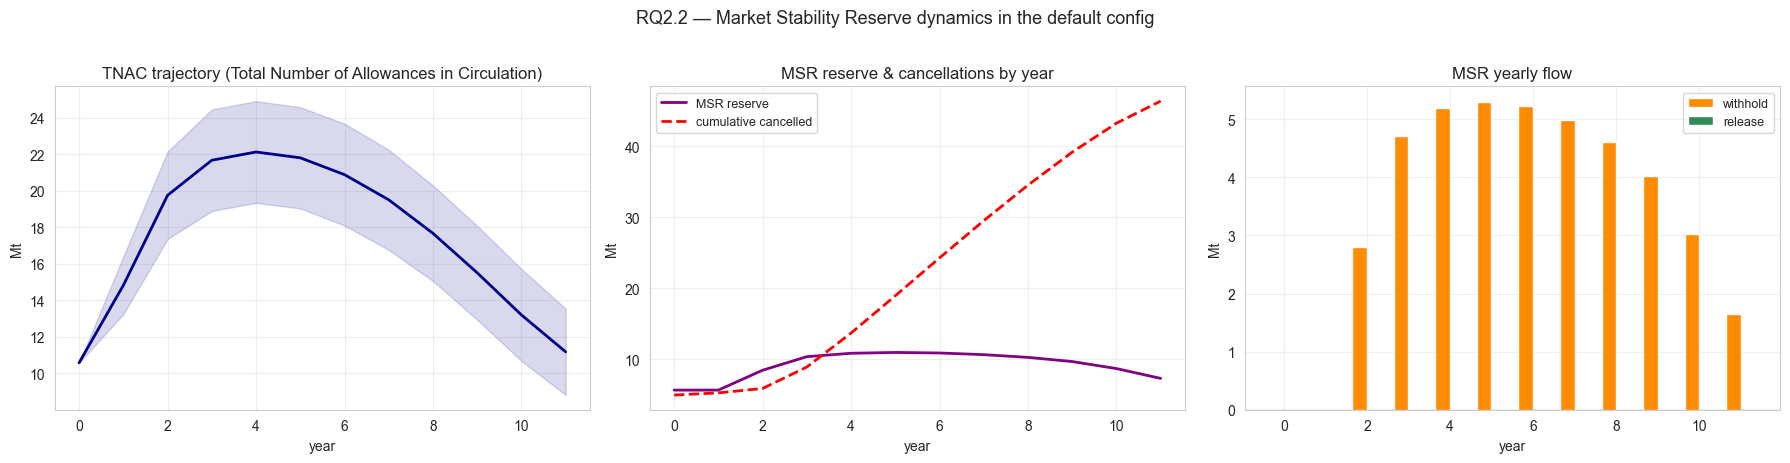

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

ax = axes[0]
if ('tnac', 'mean') in by_year.columns:
    ax.plot(by_year.index, by_year[('tnac', 'mean')], lw=2, color='darkblue')
    ax.fill_between(by_year.index,
                    by_year[('tnac', 'mean')] - by_year[('tnac', 'std')],
                    by_year[('tnac', 'mean')] + by_year[('tnac', 'std')],
                    color='darkblue', alpha=0.15)
    ax.set(title='TNAC trajectory (Total Number of Allowances in Circulation)',
           xlabel='year', ylabel='Mt')
    ax.grid(True, alpha=0.3)

ax = axes[1]
if ('msr_reserve', 'mean') in by_year.columns:
    ax.plot(by_year.index, by_year[('msr_reserve', 'mean')], lw=2, color='purple', label='MSR reserve')
if ('msr_total_cancelled', 'mean') in by_year.columns:
    ax.plot(by_year.index, by_year[('msr_total_cancelled', 'mean')], lw=2, color='red',
            linestyle='--', label='cumulative cancelled')
ax.set(title='MSR reserve & cancellations by year', xlabel='year', ylabel='Mt')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[2]
years = by_year.index.values
if ('msr_withhold_this_year', 'mean') in by_year.columns:
    wh = by_year[('msr_withhold_this_year', 'mean')]
    ax.bar(years - 0.18, wh, width=0.35, color='darkorange', label='withhold')
if ('msr_release_this_year', 'mean') in by_year.columns:
    rel = by_year[('msr_release_this_year', 'mean')]
    ax.bar(years + 0.18, rel, width=0.35, color='seagreen', label='release')
ax.axhline(0, color='black', lw=0.8)
ax.set(title='MSR yearly flow', xlabel='year', ylabel='Mt')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('RQ2.2 — Market Stability Reserve dynamics in the default config',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


### RQ2.3 — Penalty incidence and magnitude

Penalty incidence in the converged window (last 200 episodes):


,run,pct_cells_short,mean_shortfall_when_short_Mt,mean_penalty_when_short_Meur
0,default_/s738,22.984,1.452,232.124
1,default_/s219,18.000,1.008,161.883
2,default_/s581,26.286,2.551,414.429
3,default_/s904,14.391,0.957,151.054


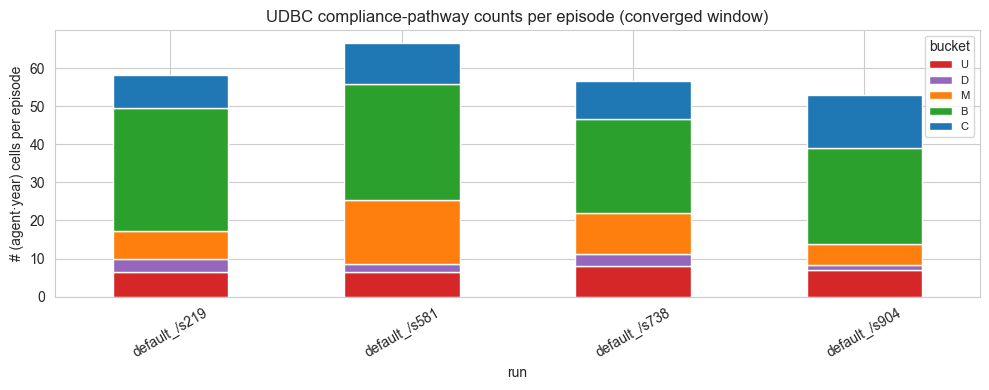

U = pure under-bid; D = pure debt-cascade; M = mixed; B = bank-covered; C = secondary-covered.


In [ ]:
# (a) Share of (agent, year) cells with shortfall > 0; (b) mean per-cell penalty when it bites.
share_rows = []
for k, run in runs.items():
    yr = tail_year_rows(run)
    sf_cols = agent_cols(yr, 'shortfall')
    pen_cols = agent_cols(yr, 'penalty')
    if not sf_cols: continue
    sf = yr[sf_cols].values.flatten()
    pen = yr[pen_cols].values.flatten() if pen_cols else None
    nc_mask = sf > 1e-6
    share_rows.append({
        'run': f'{k[0][:8]}/s{k[2]}',
        'pct_cells_short': 100.0 * nc_mask.mean() if sf.size else np.nan,
        'mean_shortfall_when_short_Mt': float(sf[nc_mask].mean()) if nc_mask.any() else 0.0,
        'mean_penalty_when_short_Meur': float(pen[nc_mask].mean()) if (pen is not None and nc_mask.any()) else 0.0,
    })
share_df = pd.DataFrame(share_rows)
print(f'Penalty incidence in the converged window (last {TAIL_EPISODES} episodes):')
display(share_df.round(3))

# UDBC mix at the system level (averaged across seeds).
ud_rows = []
for k, run in runs.items():
    ep = tail_episodes(run['ep_df'])
    for b in ['U', 'D', 'M', 'B', 'C']:
        cols = agent_cols(ep, f'udbc_{b}_total')
        if cols:
            ud_rows.append({'run': f'{k[0][:8]}/s{k[2]}', 'bucket': b,
                            'mean_total_per_episode': float(ep[cols].sum(axis=1).mean())})
if ud_rows:
    ud_df = pd.DataFrame(ud_rows).pivot(index='run', columns='bucket', values='mean_total_per_episode').fillna(0.0)
    ud_df = ud_df[[c for c in ['U', 'D', 'M', 'B', 'C'] if c in ud_df.columns]]
    fig, ax = plt.subplots(figsize=(10, 4))
    ud_df.plot(kind='bar', stacked=True, ax=ax,
               color=['#d62728', '#9467bd', '#ff7f0e', '#2ca02c', '#1f77b4'])
    ax.set(title='UDBC compliance-pathway counts per episode (converged window)',
           ylabel='# (agent·year) cells per episode', xlabel='run')
    ax.legend(title='bucket', fontsize=8); ax.tick_params(axis='x', rotation=30)
    plt.tight_layout(); plt.show()
    print('U = pure under-bid; D = pure debt-cascade; M = mixed; B = bank-covered; C = secondary-covered.')


### RQ2.4 — Decarbonisation pace

C:\Users\danie\AppData\Local\Temp\ipykernel_39204\1425922483.py:43: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


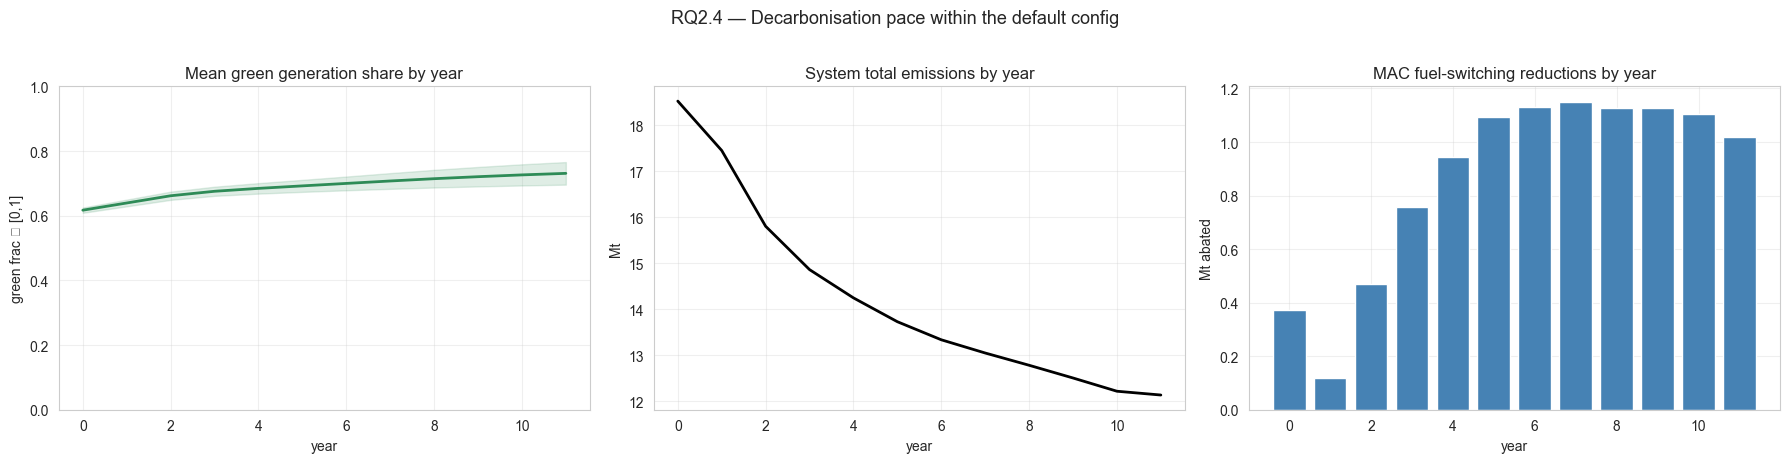

In [ ]:
# (a) Mean green_frac by year across episodes/seeds; (b) MAC reduction by year.
yr_pool2 = []
for k, run in runs.items():
    yr = tail_year_rows(run)
    keep = ['year']
    gf_cols = agent_cols(yr, 'green_frac')
    mac_cols = agent_cols(yr, 'mac_reduction')
    em_cols = agent_cols(yr, 'emissions')
    if 'year' not in yr.columns: continue
    df = yr[['year']].copy()
    if gf_cols:  df['green_frac_mean'] = yr[gf_cols].mean(axis=1)
    if mac_cols: df['mac_reduction_total'] = yr[mac_cols].sum(axis=1)
    if em_cols:  df['emissions_total'] = yr[em_cols].sum(axis=1)
    yr_pool2.append(df)
if yr_pool2:
    pool = pd.concat(yr_pool2, ignore_index=True).groupby('year').agg(['mean', 'std'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    ax = axes[0]
    if ('green_frac_mean', 'mean') in pool.columns:
        ax.plot(pool.index, pool[('green_frac_mean', 'mean')], lw=2, color='seagreen')
        ax.fill_between(pool.index,
                        pool[('green_frac_mean', 'mean')] - pool[('green_frac_mean', 'std')],
                        pool[('green_frac_mean', 'mean')] + pool[('green_frac_mean', 'std')],
                        color='seagreen', alpha=0.15)
        ax.set(title='Mean green generation share by year', xlabel='year', ylabel='green frac ∈ [0,1]')
        ax.set_ylim(0, 1); ax.grid(True, alpha=0.3)

    ax = axes[1]
    if ('emissions_total', 'mean') in pool.columns:
        ax.plot(pool.index, pool[('emissions_total', 'mean')], lw=2, color='black')
        ax.set(title='System total emissions by year', xlabel='year', ylabel='Mt')
        ax.grid(True, alpha=0.3)

    ax = axes[2]
    if ('mac_reduction_total', 'mean') in pool.columns:
        ax.bar(pool.index, pool[('mac_reduction_total', 'mean')], color='steelblue')
        ax.set(title='MAC fuel-switching reductions by year', xlabel='year', ylabel='Mt abated')
        ax.grid(True, alpha=0.3)

    plt.suptitle('RQ2.4 — Decarbonisation pace within the default config',
                 fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()


**RQ2 summary.** Within the default config, RQ2.1–2.4 give the
*descriptive* baseline of how cap, MSR, penalty, and emission outcomes
move together. The sensitivity question — *would these trajectories
look qualitatively different under a tighter LRF, or with the MSR off?*
— is what the cross-config experiments notebook will answer.

---

## §RQ3 — Strategic Behaviour and Aggregation

The default config crosses 4 archetypes (coal-heavy, gas-dominant,
transitioner, green-leader) with 2 reward weightings (pure financial,
balanced ESG). That gives us the financial-vs-environmental contrast
that RQ3 asks about, *inside one config*.

Five panels:

* **3.1** — Bidding behaviour by archetype × weighting.
* **3.2** — Investment behaviour by archetype × weighting.
* **3.3** — Secondary-market role by archetype.
* **3.4** — UDBC compliance pathway by archetype.
* **3.5** — Reward decomposition (financial vs ESG vs penalty) by weighting.

### RQ3.1 — Bidding behaviour by archetype × reward-weighting

Per-(run, agent) rows: 32


C:\Users\danie\AppData\Local\Temp\ipykernel_39204\309587121.py:55: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


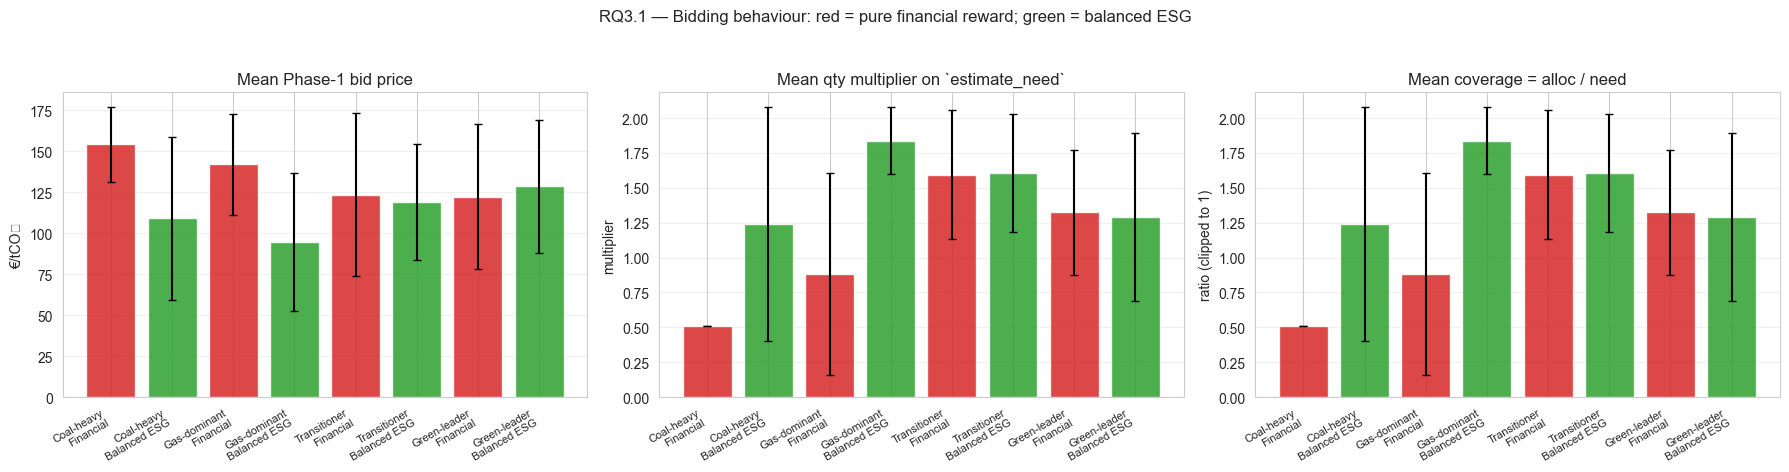

In [ ]:
# Per-agent converged-window means, then group by (archetype, weighting).
def _per_agent_table(run, episode_cols, year_cols):
    """Return list of dicts (one per agent) with mean values from converged window."""
    ep = tail_episodes(run['ep_df'])
    yr = tail_year_rows(run)
    rows = []
    for i in range(N_AGENTS):
        row = {'agent_idx': i, 'archetype': _agent_archetype(i), 'weighting': _agent_weighting(i)}
        for prefix in episode_cols:
            col = f'{prefix}_A{i+1}'
            row[prefix] = float(ep[col].mean()) if col in ep.columns else np.nan
        for prefix in year_cols:
            col = f'{prefix}_A{i+1}'
            row[prefix] = float(yr[col].mean()) if col in yr.columns else np.nan
        rows.append(row)
    return rows

agent_rows = []
for k, run in runs.items():
    for r in _per_agent_table(
        run,
        episode_cols=['bid_price', 'avg_bid_mult', 'avg_bid_coverage',
                      'sec_buy_vol', 'sec_sell_vol', 'sec_buy_avg_px', 'sec_sell_avg_px',
                      'sec_buy_years', 'sec_sell_years',
                      'invest_cost', 'green_frac', 'delta_green',
                      'mean_alloc', 'penalty', 'shortfall', 'reward', 'reward_base',
                      'inv_onshore_share', 'inv_offshore_share', 'inv_solar_share'],
        year_cols=['mac_reduction', 'mac_cost'],
    ):
        r.update({'sweep': k[0], 'seed': k[2]})
        agent_rows.append(r)
agent_df = pd.DataFrame(agent_rows)
print(f'Per-(run, agent) rows: {len(agent_df)}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
order = [(arch, w) for arch in ARCHETYPES for w in ['Financial', 'Balanced ESG']]
labels = [f'{a}\n{w}' for a, w in order]

def _bar(ax, col, title, ylabel):
    means = []; stds = []
    for arch, w in order:
        sub = agent_df[(agent_df['archetype'] == arch) & (agent_df['weighting'] == w)][col]
        means.append(sub.mean()); stds.append(sub.std())
    x = np.arange(len(order))
    colors = ['#d62728' if w == 'Financial' else '#2ca02c' for _, w in order]
    ax.bar(x, means, yerr=stds, color=colors, capsize=3, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8, rotation=30, ha='right')
    ax.set(title=title, ylabel=ylabel); ax.grid(True, alpha=0.3, axis='y')

_bar(axes[0], 'bid_price',         'Mean Phase-1 bid price', '€/tCO₂')
_bar(axes[1], 'avg_bid_mult',      'Mean qty multiplier on `estimate_need`', 'multiplier')
_bar(axes[2], 'avg_bid_coverage',  'Mean coverage = alloc / need', 'ratio (clipped to 1)')
plt.suptitle('RQ3.1 — Bidding behaviour: red = pure financial reward; green = balanced ESG',
             fontsize=12, y=1.04)
plt.tight_layout(); plt.show()


### RQ3.2 — Investment behaviour

C:\Users\danie\AppData\Local\Temp\ipykernel_39204\1602023298.py:7: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


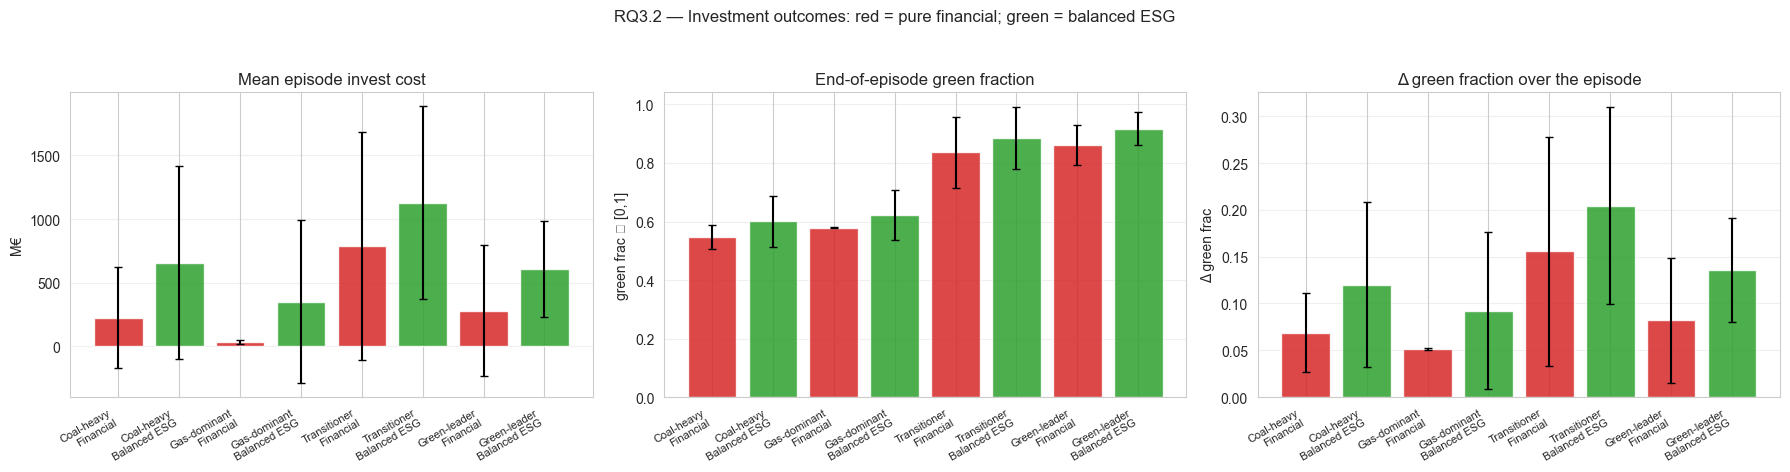

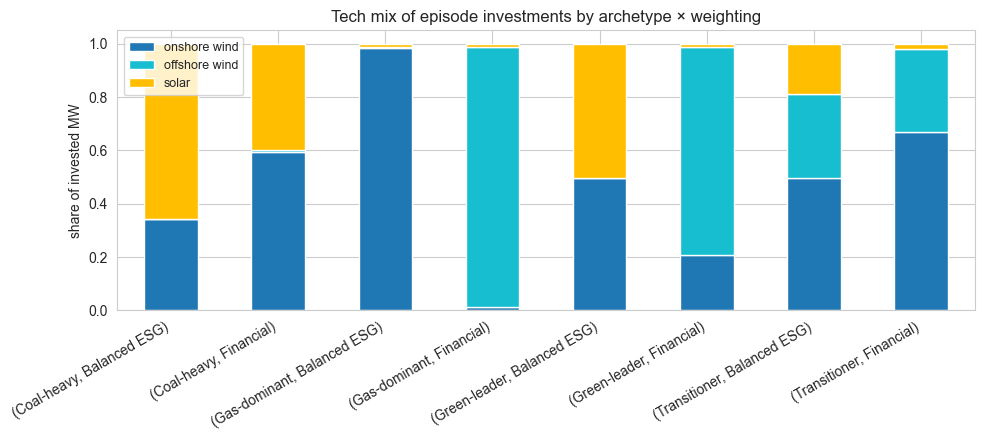

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
_bar(axes[0], 'invest_cost', 'Mean episode invest cost', 'M€')
_bar(axes[1], 'green_frac',  'End-of-episode green fraction', 'green frac ∈ [0,1]')
_bar(axes[2], 'delta_green', 'Δ green fraction over the episode', 'Δ green frac')
plt.suptitle('RQ3.2 — Investment outcomes: red = pure financial; green = balanced ESG',
             fontsize=12, y=1.04)
plt.tight_layout(); plt.show()

# Tech mix by archetype × weighting (stacked bar).
tech_means = (agent_df.groupby(['archetype', 'weighting'])
              [['inv_onshore_share', 'inv_offshore_share', 'inv_solar_share']].mean())
fig, ax = plt.subplots(figsize=(10, 4.5))
tech_means.plot(kind='bar', stacked=True, ax=ax,
                color=['#1f77b4', '#17becf', '#ffbf00'])
ax.set(title='Tech mix of episode investments by archetype × weighting',
       ylabel='share of invested MW', xlabel='')
ax.legend(['onshore wind', 'offshore wind', 'solar'], fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()


### RQ3.3 — Secondary-market role

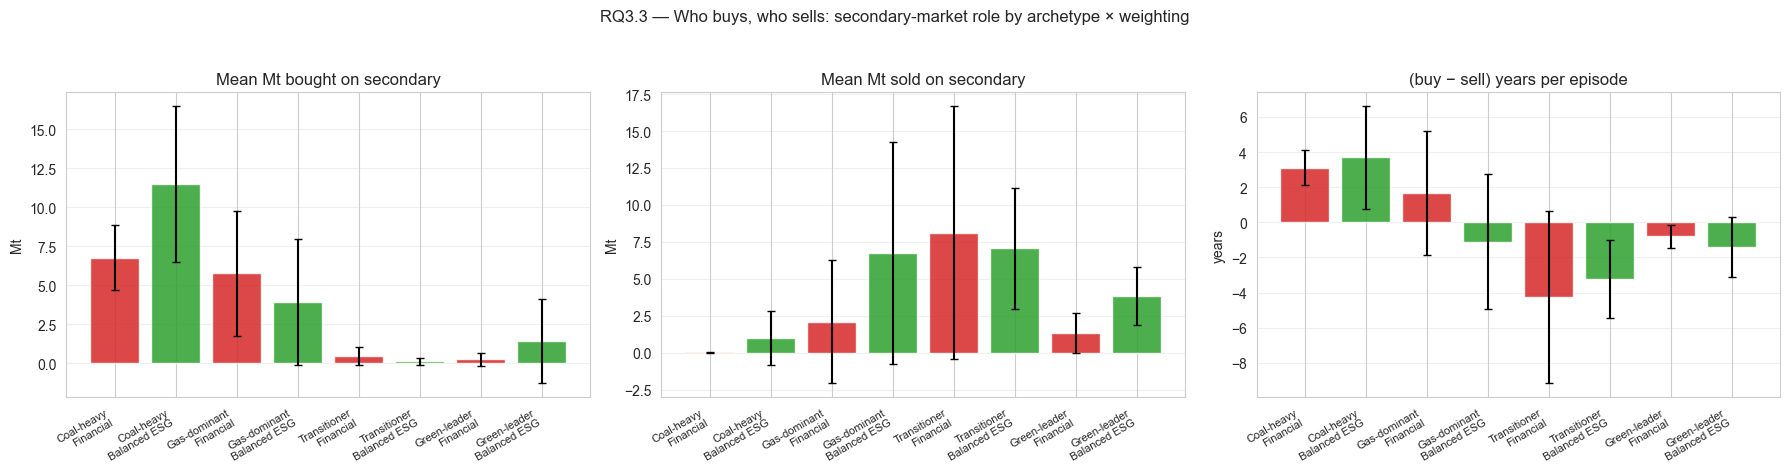

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
_bar(axes[0], 'sec_buy_vol',    'Mean Mt bought on secondary',  'Mt')
_bar(axes[1], 'sec_sell_vol',   'Mean Mt sold on secondary',    'Mt')
# Net buyer/seller years (out of 12).
def _net_buyer_years(row):
    by = row.get('sec_buy_years', np.nan); sy = row.get('sec_sell_years', np.nan)
    if pd.isna(by) or pd.isna(sy): return np.nan
    return by - sy
agent_df['net_buyer_years'] = agent_df.apply(_net_buyer_years, axis=1)
_bar(axes[2], 'net_buyer_years', '(buy − sell) years per episode', 'years')
plt.suptitle('RQ3.3 — Who buys, who sells: secondary-market role by archetype × weighting',
             fontsize=12, y=1.04)
plt.tight_layout(); plt.show()


### RQ3.4 — Compliance pathway (UDBC) by archetype × weighting

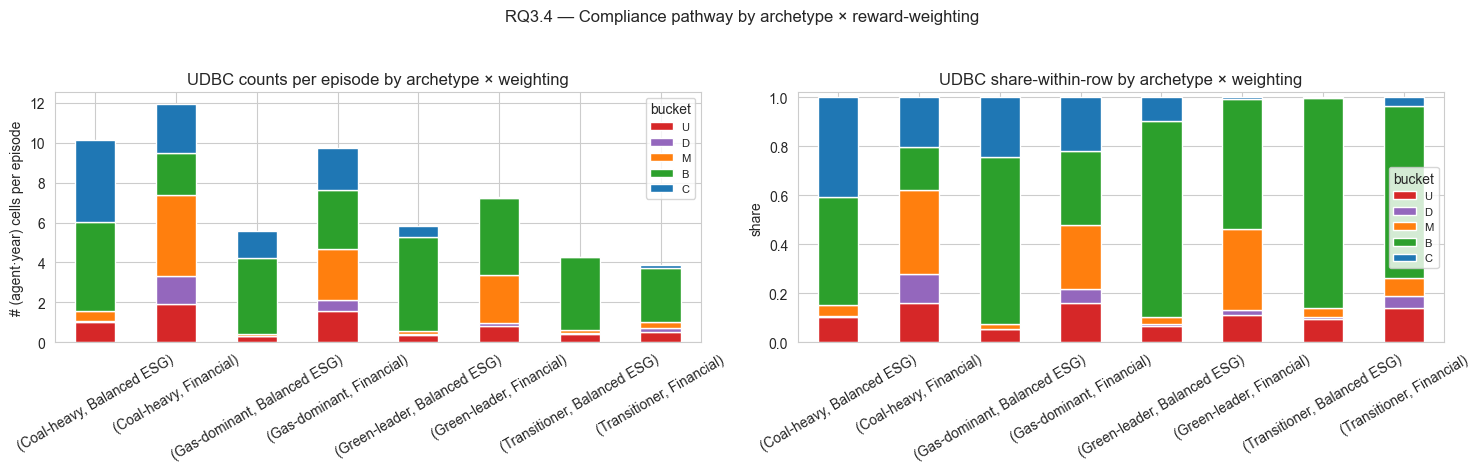

In [ ]:
# Mean per-agent UDBC totals → grouped by archetype × weighting → stacked bar of shares.
udbc_buckets = ['U', 'D', 'M', 'B', 'C']
udbc_rows = []
for k, run in runs.items():
    ep = tail_episodes(run['ep_df'])
    for i in range(N_AGENTS):
        row = {'archetype': _agent_archetype(i), 'weighting': _agent_weighting(i)}
        for b in udbc_buckets:
            col = f'udbc_{b}_total_A{i+1}'
            row[b] = float(ep[col].mean()) if col in ep.columns else 0.0
        udbc_rows.append(row)
udbc_df = pd.DataFrame(udbc_rows)
udbc_grouped = udbc_df.groupby(['archetype', 'weighting'])[udbc_buckets].mean()
udbc_share = udbc_grouped.div(udbc_grouped.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
udbc_grouped.plot(kind='bar', stacked=True, ax=axes[0],
                  color=['#d62728', '#9467bd', '#ff7f0e', '#2ca02c', '#1f77b4'])
axes[0].set(title='UDBC counts per episode by archetype × weighting',
            ylabel='# (agent·year) cells per episode', xlabel='')
axes[0].legend(title='bucket', fontsize=8)
axes[0].tick_params(axis='x', rotation=30)

udbc_share.plot(kind='bar', stacked=True, ax=axes[1],
                color=['#d62728', '#9467bd', '#ff7f0e', '#2ca02c', '#1f77b4'])
axes[1].set(title='UDBC share-within-row by archetype × weighting',
            ylabel='share', xlabel='')
axes[1].set_ylim(0, 1.02)
axes[1].legend(title='bucket', fontsize=8)
axes[1].tick_params(axis='x', rotation=30)
plt.suptitle('RQ3.4 — Compliance pathway by archetype × reward-weighting',
             fontsize=12, y=1.04)
plt.tight_layout(); plt.show()


### RQ3.5 — Reward decomposition: financial vs balanced-ESG agents

Per-archetype × weighting mean reward decomposition (M€-scale, post-normalisation units):


reward  reward_base  shaping  penalty  invest_cost
archetype    weighting                                                       
Coal-heavy   Balanced ESG   -2.78        -3.30     0.52   210.20       656.59
             Financial      -8.30        -8.76     0.46  1751.09       222.69
Gas-dominant Balanced ESG    1.13         0.62     0.51    51.78       347.68
             Financial      -6.17        -6.67     0.50   964.10        31.15
Green-leader Balanced ESG    4.83         4.30     0.53    37.26       604.87
             Financial      -4.26        -4.75     0.49  1974.08       278.17
Transitioner Balanced ESG    5.49         4.96     0.53    54.19      1128.48
             Financial       4.33         3.82     0.51    73.32       789.30

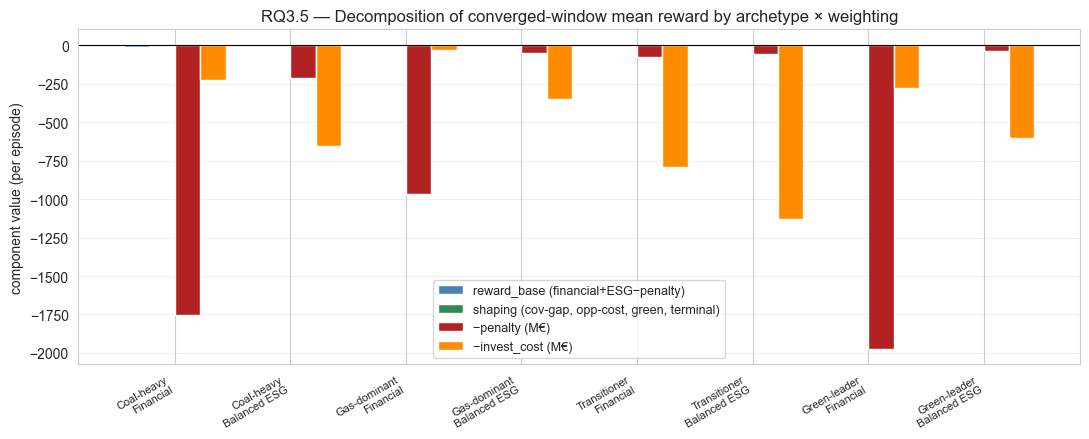

In [ ]:
# At the (run, agent) level we have reward_base = financial - penalty + ESG (pre-shaping).
# We don't have the financial / ESG / penalty buckets cleanly split in the episode CSV (they're
# combined into reward_base), so we use what IS exposed: penalty_A{i}, invest_cost_A{i},
# reward_A{i}, reward_base_A{i}.

decomp = agent_df.groupby(['archetype', 'weighting'])[['reward', 'reward_base', 'penalty', 'invest_cost']].mean()
decomp['shaping'] = decomp['reward'] - decomp['reward_base']
decomp_print = decomp[['reward', 'reward_base', 'shaping', 'penalty', 'invest_cost']].round(2)
print('Per-archetype × weighting mean reward decomposition (M€-scale, post-normalisation units):')
display(decomp_print)

fig, ax = plt.subplots(figsize=(11, 4.5))
order = [(a, w) for a in ARCHETYPES for w in ['Financial', 'Balanced ESG']]
labels = [f'{a}\n{w}' for a, w in order]
x = np.arange(len(order))
width = 0.22

rew_b   = [decomp.loc[(a, w), 'reward_base']  for a, w in order]
shape_  = [decomp.loc[(a, w), 'shaping']      for a, w in order]
pen     = [decomp.loc[(a, w), 'penalty']      for a, w in order]
inv     = [decomp.loc[(a, w), 'invest_cost']  for a, w in order]

ax.bar(x - 1.5 * width, rew_b,  width, label='reward_base (financial+ESG−penalty)', color='steelblue')
ax.bar(x - 0.5 * width, shape_, width, label='shaping (cov-gap, opp-cost, green, terminal)', color='seagreen')
ax.bar(x + 0.5 * width, -np.asarray(pen), width, label='−penalty (M€)', color='firebrick')
ax.bar(x + 1.5 * width, -np.asarray(inv), width, label='−invest_cost (M€)', color='darkorange')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8, rotation=30, ha='right')
ax.set(title='RQ3.5 — Decomposition of converged-window mean reward by archetype × weighting',
       ylabel='component value (per episode)')
ax.legend(fontsize=9, loc='best'); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


**Aggregation note.** The system-level outcomes that RQ3 asks
about — total clearing price, system green fraction, total penalty
volume — are exactly what RQ1.2 / RQ1.3 / RQ2.1 already report. The
missing piece RQ3 adds is *attribution*: which archetypes drive those
aggregates? The §RQ3 panels above answer that — and in particular,
panels 3.1 / 3.4 / 3.5 contrast the pure-financial agent (red) against
its balanced-ESG twin (green) within each archetype, which is the
direct test of "how do financial vs environmental objectives shape
strategy".

---

### RQ4 — Compliance pressure, debt cascade, and credit stress

These panels read from the v8.6.1 expanded year-log columns. Cells silently
no-op on logs from older versions (every column access is guarded by
`if col in df.columns`). The four sub-questions are:

* **RQ4.1** — Does coverage gap (`max(0, need − alloc)` Mt) shrink as agents
  learn to size their auction bids? Is the residual gap eaten by the
  secondary market or does it propagate as carry-forward debt?
* **RQ4.2** — Auction concentration: does the system stabilise around a
  diffuse allocation, or does a small subset of bidders capture most volume
  (HHI / max-agent-share)?
* **RQ4.3** — Secondary-market liquidity: how many agents participate
  on each side, and what fraction of intent gets executed?
* **RQ4.4** — Credit stress in the converged window: peak emergency-loan
  balance and peak carry-forward debt by archetype × reward-weighting.


### RQ4.1 — Coverage gap & carry-forward trajectory

In [ ]:
# RQ4.1 — Per-year coverage gap and end-of-year carry-forward (debt cascade).
# Cross-seed median + ±1 std fan, computed from the year_log only — works on
# any v8.6.1+ run. Earlier logs silently produce empty figures.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _stack_year_metric(prefix, max_idx=N_TOTAL, agg="sum"):
    """Return wide DataFrame indexed by year with one column per run, where
    each value is the cross-agent (sum|mean) of `{prefix}_A{i}` for that
    year — averaged across episodes within the run."""
    out = {}
    for k, run in runs.items():
        yr = run["yr_df"]
        if "year" not in yr.columns:
            continue
        cols = [f"{prefix}_A{i+1}" for i in range(max_idx)
                if f"{prefix}_A{i+1}" in yr.columns]
        if not cols:
            continue
        # Per-year mean across episodes of the cross-agent agg.
        if agg == "sum":
            per_year = yr.groupby("year")[cols].mean().sum(axis=1)
        else:
            per_year = yr.groupby("year")[cols].mean().mean(axis=1)
        out[k] = per_year
    return pd.concat(out, axis=1).sort_index() if out else pd.DataFrame()

cov_gap_df  = _stack_year_metric("coverage_gap")             # system-sum (Mt)
cf_end_df   = _stack_year_metric("carry_forward_end")        # system-sum (Mt)
cf_start_df = _stack_year_metric("carry_forward_start")      # system-sum (Mt)

if cov_gap_df.empty and cf_end_df.empty:
    print("[RQ4.1] coverage_gap_A* / carry_forward_*_A* columns missing — pre-8.6.1 log.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, df, ttl in [
        (axes[0], cov_gap_df, "System coverage gap (Mt) — pre-secondary"),
        (axes[1], cf_end_df,  "System end-of-year carry-forward (Mt)"),
    ]:
        if df.empty:
            ax.set_title(ttl + "\n(missing)"); continue
        med = df.median(axis=1); std = df.std(axis=1)
        ax.fill_between(med.index, med - std, med + std, alpha=0.2, color="steelblue")
        ax.plot(med.index, med, "o-", color="steelblue", label="median across seeds")
        ax.set_xlabel("Year"); ax.set_ylabel("Mt"); ax.set_title(ttl)
        ax.grid(alpha=0.3); ax.legend(loc="best", fontsize=9)
    plt.tight_layout(); plt.show()


[RQ4.1] coverage_gap_A* / carry_forward_*_A* columns missing — pre-8.6.1 log.


### RQ4.2 — Auction concentration (HHI, max-agent share)

In [ ]:
# RQ4.2 — Auction concentration trajectory. Reads `auction_hhi` and
# `auction_max_agent_share` (year-level scalars added in v8.6.1).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _stack_year_scalar(col):
    out = {}
    for k, run in runs.items():
        yr = run["yr_df"]
        if "year" not in yr.columns or col not in yr.columns:
            continue
        out[k] = yr.groupby("year")[col].mean()
    return pd.concat(out, axis=1).sort_index() if out else pd.DataFrame()

hhi_df = _stack_year_scalar("auction_hhi")
mas_df = _stack_year_scalar("auction_max_agent_share")
fail_df = _stack_year_scalar("auction_failed")
unsold_df = _stack_year_scalar("auction_unsold")

if hhi_df.empty and mas_df.empty:
    print("[RQ4.2] auction_hhi / auction_max_agent_share missing — pre-8.6.1 log.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, df, ttl, ylabel in [
        (axes[0], hhi_df, "Auction HHI (allocation concentration)", "HHI"),
        (axes[1], mas_df, "Max single-agent share", "Share"),
        (axes[2], unsold_df, "Auction unsold (Mt)", "Mt"),
    ]:
        if df.empty:
            ax.set_title(ttl + "\n(missing)"); continue
        med = df.median(axis=1); std = df.std(axis=1)
        ax.fill_between(med.index, med - std, med + std, alpha=0.2, color="darkorange")
        ax.plot(med.index, med, "o-", color="darkorange")
        ax.set_xlabel("Year"); ax.set_ylabel(ylabel); ax.set_title(ttl)
        ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    if not fail_df.empty:
        n_failures = int(np.nansum(fail_df.values))
        print(f"Total auction-failure (year, seed) cells across loaded runs: {n_failures}")


[RQ4.2] auction_hhi / auction_max_agent_share missing — pre-8.6.1 log.


### RQ4.3 — Secondary-market liquidity (intent vs execution)

In [ ]:
# RQ4.3 — Secondary-market participation: how many agents posted intent
# vs how many actually traded? A wide intent-execution gap means agents
# repeatedly try to clear at uncrossable prices.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cols = {
    "buyers_intent":   "secondary_n_buyers_intent",
    "sellers_intent":  "secondary_n_sellers_intent",
    "buyers_executed": "secondary_n_buyers_executed",
    "sellers_executed":"secondary_n_sellers_executed",
}
present = {label: col for label, col in cols.items() if any(col in run["yr_df"].columns for run in runs.values())}

if not present:
    print("[RQ4.3] secondary_n_*_intent/executed columns missing — pre-8.6.1 log.")
else:
    fig, ax = plt.subplots(figsize=(11, 4))
    for label, col in present.items():
        rows = []
        for k, run in runs.items():
            yr = run["yr_df"]
            if col not in yr.columns or "year" not in yr.columns:
                continue
            rows.append(yr.groupby("year")[col].mean())
        if not rows:
            continue
        s = pd.concat(rows, axis=1).median(axis=1)
        ls = "-" if "executed" in label else "--"
        ax.plot(s.index, s, ls + "o", label=label)
    ax.set_xlabel("Year"); ax.set_ylabel("Number of agents")
    ax.set_title("Secondary-market participation — intent vs executed")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


[RQ4.3] secondary_n_*_intent/executed columns missing — pre-8.6.1 log.


### RQ4.4 — Converged-window credit stress by archetype × weighting

In [ ]:
# RQ4.4 — Per-(archetype, weighting) cell of the mean peak emergency-loan
# balance and peak carry-forward debt in the converged window. Sourced from
# the per-episode `peak_loan_outstanding_A{i}` / `peak_carry_forward_A{i}`
# (v8.6.1+); pre-8.6.1 logs lack these columns and produce an empty table.
import numpy as np
import pandas as pd

def _converged_credit_metrics():
    rows = []
    for k, run in runs.items():
        ep_tail = tail_episodes(run["ep_df"])
        cfg = run["config"]
        for i in range(N_AGENTS):
            arche = ARCHETYPES[i // 2] if i // 2 < len(ARCHETYPES) else f"A{i+1}"
            w_cost, w_green = (cfg.get("companies", {}).get("reward_weights") or [[1, 0]] * N_AGENTS)[i]
            weighting = "Financial" if w_green < 0.25 else ("ESG" if w_green > 0.75 else "Balanced")
            row = {"sweep": k[0], "variant": k[1], "seed": k[2],
                   "archetype": arche, "weighting": weighting, "agent": i + 1}
            for stub in ["peak_loan_outstanding", "peak_carry_forward",
                         "final_treasury_reserve"]:
                col = f"{stub}_A{i+1}"
                row[stub] = float(ep_tail[col].mean()) if col in ep_tail.columns else np.nan
            rows.append(row)
    return pd.DataFrame(rows)

credit_df = _converged_credit_metrics()
if credit_df.empty or credit_df[["peak_loan_outstanding", "peak_carry_forward"]].isna().all().all():
    print("[RQ4.4] peak_loan_outstanding_A* / peak_carry_forward_A* missing — pre-8.6.1 log.")
else:
    pivot_loan = credit_df.pivot_table(
        index="archetype", columns="weighting", values="peak_loan_outstanding", aggfunc="mean"
    ).round(3)
    pivot_cf = credit_df.pivot_table(
        index="archetype", columns="weighting", values="peak_carry_forward", aggfunc="mean"
    ).round(3)
    print("Mean peak emergency-loan balance (M€) — converged window:")
    display(pivot_loan)
    print("\nMean peak end-of-year carry-forward (Mt) — converged window:")
    display(pivot_cf)


[RQ4.4] peak_loan_outstanding_A* / peak_carry_forward_A* missing — pre-8.6.1 log.


**RQ4 summary.** RQ4.1–4.3 give the run-level
mechanics: did the agents close the coverage gap, did the auction stay
diffuse, and did the secondary market actually clear the residual? RQ4.4
attributes the residual debt and emergency-loan usage to the
(archetype × weighting) cells — the financial vs ESG split is the most
informative cut here, since coal-heavy financial agents are the ones for
whom the gap-penalty reward (driven by `effective_penalty_rate`) actively
dominates the bid head.

---

---

## What this notebook does **not** answer

* Cross-config sensitivity — needs sweep variants. *Out of scope here.*
* Causal attribution of regulatory mechanisms (e.g. counterfactual
  "what if MSR were off") — needs sweep variants.
* Real-world EU-ETS empirical validation beyond the qualitative
  price-band check in RQ1.3.
* Strategy clustering, theory tests (LCOE crossover, archetype
  heterogeneity), and predictive models of clearing price — these are
  in the analysis plan (`planning/data_science_analysis_plan.md` §B1, B2,
  B4) and will get their own notebooks where they can be evaluated
  cleanly with cross-validation.

The default-config evidence base assembled above is the *baseline* that
those follow-on analyses will perturb and test against.